# 04g Taiwan Socioeconomic Features

將台灣教育程度與失業率資料整理為 DeepSolar top-90 對應的 socioeconomic 特徵，供 Stage 2 transfer learning 使用。

**地理單位**：**鄉鎮市區**（368 列，`TOWNCODE` 對齊人口表）；原始資料為縣市層級，同縣市各鄉鎮複製相同數值

**時間維度**：教育程度為民國 **109** 年快照；`employ_rate` 為民國 **102–113** 年各縣市就業率之歷年平均

**Input**：
- `data/taiwan/socioeconomic/縣市鄉鎮最高學歷資料/t011*.xlsx`（表 11 最高學歷）
- `data/taiwan/socioeconomic/county_unemployment_102_113.csv`

**Output**：`data/taiwan/socioeconomic/taiwan_socioeconomic_features.csv`

**交接說明**：`data/taiwan/socioeconomic/04g_taiwan_socioeconomic_summary.md`

## DeepSolar 欄位對應（僅 top-90）

| DeepSolar 欄位 | 台灣來源 |
|---|---|
| `education_college` | 大專及以上人口 |
| `education_*_rate` | 各教育人口 / 15 歲以上常住人口總計 |
| `education_bachelor` 等 | 原始表無細分 → **不輸出** |
| `education_high_school_graduate` | 高級中等 |
| `education_less_than_high_school` | 國小及以下 + 國（初）中 |
| `employ_rate` | `1 - unemployment_rate`（失業率 ÷ 100） |


In [1]:
# %%
# 1. Imports

import re
import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJ = Path('..').resolve()
SOCIO_DIR = PROJ / 'data' / 'taiwan' / 'socioeconomic'
POP_CSV = PROJ / 'data' / 'taiwan' / 'population' / 'taiwan_population_features.csv'
EDU_DIR = SOCIO_DIR / '縣市鄉鎮最高學歷資料'
UNEMP_CSV = SOCIO_DIR / 'county_unemployment_102_113.csv'
OUT_CSV = SOCIO_DIR / 'taiwan_socioeconomic_features.csv'

SOCIO_DIR.mkdir(parents=True, exist_ok=True)

ID_COLS = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME']

COUNTIES_22 = {
    '基隆市', '臺北市', '新北市', '桃園市', '新竹市', '新竹縣', '苗栗縣',
    '臺中市', '彰化縣', '南投縣', '雲林縣', '嘉義市', '嘉義縣', '臺南市',
    '高雄市', '屏東縣', '宜蘭縣', '花蓮縣', '臺東縣', '澎湖縣', '金門縣', '連江縣',
}

EMPLOYMENT_FEATURES = ['employ_rate']

print('Project root:', PROJ)
print('Education dir:', EDU_DIR, EDU_DIR.exists())
print('Unemployment csv:', UNEMP_CSV.exists())
print('Population ref:', POP_CSV.exists())



Project root: /Users/tingting/SolarPotentialMapping
Education dir: /Users/tingting/SolarPotentialMapping/data/taiwan/socioeconomic/縣市鄉鎮最高學歷資料 True
Unemployment csv: True
Population ref: True


## Helper functions


In [2]:
def discover_education_files(edu_dir: Path) -> list[Path]:
    files = sorted({p.resolve() for p in edu_dir.glob('t011*.xlsx')})
    if not files:
        raise FileNotFoundError(f'No t011 education xlsx under {edu_dir}')
    return files


def discover_unemployment_file(socio_dir: Path) -> Path:
    candidates = sorted(socio_dir.glob('*unemployment*.csv'))
    if not candidates:
        raise FileNotFoundError(f'No unemployment csv under {socio_dir}')
    return candidates[0]


def normalize_county_name(name) -> Optional[str]:
    """台→臺、去空白、統一縣市格式。"""
    if pd.isna(name):
        return None
    s = str(name).strip().replace('台', '臺')
    s = re.sub(r'\s+', '', s)
    for suffix in ('市', '縣'):
        if s.endswith(suffix * 2):
            s = s[:-len(suffix)]
    return s if s in COUNTIES_22 else None


def parse_numeric_series(s: pd.Series) -> pd.Series:
    if s.dtype.kind in 'biufc':
        return pd.to_numeric(s, errors='coerce')
    cleaned = (
        s.astype(str).str.strip()
        .replace({'': np.nan, 'nan': np.nan, 'None': np.nan, '-': np.nan, '*': np.nan})
    )
    cleaned = cleaned.str.replace(',', '', regex=False)
    return pd.to_numeric(cleaned, errors='coerce')


def clean_row_label(label) -> str:
    s = str(label).strip()
    s = re.sub(r'^[\d０-９\s\u3000]+', '', s)
    s = re.sub(r'[\s\u3000]+', '', s)
    return s.replace('台', '臺')


def extract_county_from_title(cell) -> Optional[str]:
    s = str(cell)
    if not re.search(r'表\s*1\s*1|表１１', s):
        return None
    rest = s[re.search(r'表\s*1\s*1|表１１', s).end():]
    m = re.match(r'[　\s]*(.+?[市縣])', rest)
    return normalize_county_name(m.group(1)) if m else None


def extract_year_roc(raw: pd.DataFrame) -> Optional[int]:
    for i in range(min(8, len(raw))):
        for col in range(min(6, raw.shape[1])):
            m = re.search(r'民國\s*(\d+)\s*年', str(raw.iloc[i, col]))
            if m:
                return int(m.group(1))
    return None


def classify_education_columns(header_row: pd.Series) -> dict[str, int]:
    roles: dict[str, int] = {}
    for idx, val in header_row.items():
        if pd.isna(val):
            continue
        text = str(val).replace('\n', ' ').lower()
        zh = str(val).replace('\n', '')
        if '總' in zh and '計' in zh and 'total' not in roles:
            roles['total'] = int(idx)
        elif any(k in zh for k in ('國小',)) or 'elementary' in text:
            roles['elem_below'] = int(idx)
        elif any(k in zh for k in ('國（初）中', '國(初)中', '國中')) or 'junior high' in text:
            roles['junior_high'] = int(idx)
        elif '高級' in zh or 'senior high' in text:
            roles['senior_high'] = int(idx)
        elif any(k in zh for k in ('大專', '專科', '大學')) or 'junior college' in text:
            roles['college_plus'] = int(idx)
        elif '博士' in zh or 'doctoral' in text:
            roles['doctoral'] = int(idx)
        elif '碩士' in zh or 'master' in text:
            roles['master'] = int(idx)
        elif '學士' in zh or 'bachelor' in text:
            roles['bachelor'] = int(idx)
        elif '專科' in zh and '大專' not in zh:
            roles['associate'] = int(idx)
    if 'total' not in roles:
        roles['total'] = 2
    return roles


def find_education_header(raw: pd.DataFrame) -> tuple[int, dict[str, int]]:
    for i in range(min(20, len(raw))):
        row = raw.iloc[i]
        row_text = ' '.join(str(x) for x in row if pd.notna(x))
        if ('總' in row_text and '計' in row_text) and (
            '高級' in row_text or 'senior' in row_text.lower()
        ):
            roles = classify_education_columns(row)
            if 'total' in roles:
                return i, roles
    return 8, {'total': 2, 'elem_below': 3, 'junior_high': 4, 'senior_high': 5, 'college_plus': 6}


def find_data_start_row(raw: pd.DataFrame) -> Optional[int]:
    for i in range(len(raw)):
        text = str(raw.iloc[i, 1]) if raw.shape[1] > 1 else ''
        if '按鄉鎮' in text or 'By Township' in text:
            return i + 1
    return None


def load_education_file(path: Path) -> pd.DataFrame:
    return pd.read_excel(path, header=None)


def parse_education_file(path: Path) -> pd.DataFrame:
    raw = load_education_file(path)
    county = next(
        (
            extract_county_from_title(raw.iloc[i, 1])
            for i in range(min(10, len(raw)))
            if extract_county_from_title(raw.iloc[i, 1]) is not None
        ),
        None,
    )
    if county is None:
        raise ValueError(f'Cannot detect county from title: {path.name}')

    year_roc = extract_year_roc(raw) or 109
    start = find_data_start_row(raw)
    if start is None:
        raise ValueError(f'Cannot find township section: {path.name}')

    _, colmap = find_education_header(raw)
    records: list[dict] = []
    for j in range(start, len(raw)):
        label = clean_row_label(raw.iloc[j, 1] if raw.shape[1] > 1 else '')
        if not label or label.startswith('註') or 'note' in label.lower():
            break
        if re.search(r'[a-zA-Z]', label) and not label.endswith(('市', '縣', '區', '鄉', '鎮')):
            continue

        total = parse_numeric_series(pd.Series([raw.iloc[j, colmap['total']]])).iloc[0]
        if pd.isna(total) or total <= 0:
            continue

        level = 'county' if label == county else 'township'
        rec: dict = {
            'source_file': path.name,
            'county': county,
            'level': level,
            'year_roc': year_roc,
            'year': year_roc + 1911,
            'education_population_total': float(total),
        }
        for role, idx in colmap.items():
            if role == 'total':
                continue
            val = parse_numeric_series(pd.Series([raw.iloc[j, idx]])).iloc[0]
            rec[f'edu_{role}'] = float(val) if pd.notna(val) else np.nan
        records.append(rec)

    return pd.DataFrame(records)


def build_education_features(county_df: pd.DataFrame) -> pd.DataFrame:
    """County-level education counts and rates (ROC 109 snapshot)."""
    total = county_df['education_population_total']
    elem = county_df.get('edu_elem_below', np.nan)
    jun = county_df.get('edu_junior_high', np.nan)
    sen = county_df.get('edu_senior_high', np.nan)
    college = county_df.get('edu_college_plus', np.nan)

    return (
        county_df[['county']]
        .assign(
            education_high_school_graduate=sen,
            education_less_than_high_school=elem + jun,
            education_college=college,
        )
        .assign(
            education_college_rate=lambda d: d['education_college'] / total.values,
            education_high_school_graduate_rate=lambda d: d['education_high_school_graduate'] / total.values,
            education_less_than_high_school_rate=lambda d: d['education_less_than_high_school'] / total.values,
        )
        .rename(columns={'county': 'COUNTYNAME'})
    )


def aggregate_employ_rate_by_county(emp_panel: pd.DataFrame) -> pd.DataFrame:
    """Multi-year mean employ_rate per county (102–113)."""
    return (
        emp_panel.groupby('county', as_index=False)['employ_rate']
        .mean()
        .rename(columns={'county': 'COUNTYNAME'})
        .sort_values('COUNTYNAME')
        .reset_index(drop=True)
    )


def merge_county_socioeconomic(
    education: pd.DataFrame, employment: pd.DataFrame
) -> pd.DataFrame:
    return education.merge(employment, on='COUNTYNAME', how='outer')


def expand_county_to_township(county_df: pd.DataFrame, pop_ref: pd.DataFrame) -> pd.DataFrame:
    """Replicate county-level features to all townships (same as 04e FIT)."""
    feature_cols = [c for c in county_df.columns if c != 'COUNTYNAME']
    return (
        pop_ref[ID_COLS]
        .merge(county_df, on='COUNTYNAME', how='left')
        .sort_values('TOWNCODE')
        .reset_index(drop=True)
    )


def drop_all_null_columns(df: pd.DataFrame, id_cols: list[str]) -> pd.DataFrame:
    """Omit feature columns that are entirely missing."""
    feature_cols = [c for c in df.columns if c not in id_cols]
    keep = [c for c in feature_cols if df[c].notna().any()]
    return df[id_cols + keep]


def standardize_unemployment_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={c: str(c).strip() for c in df.columns})
    rename = {'民國年': 'year_roc', '西元年': 'year', '縣市': 'county_raw', '失業率': 'unemployment_pct'}
    return df.rename(columns={k: v for k, v in rename.items() if k in df.columns})


def build_employment_features(unemp: pd.DataFrame) -> pd.DataFrame:
    return (
        unemp
        .assign(
            county=lambda d: d['county_raw'].map(normalize_county_name),
            year=lambda d: pd.to_numeric(d['year'], errors='coerce').astype('Int64'),
            year_roc=lambda d: pd.to_numeric(d['year_roc'], errors='coerce').astype('Int64'),
        )
        .loc[lambda d: d['county'].notna() & d['year'].notna()]
        .assign(
            unemployment_rate=lambda d: parse_numeric_series(d['unemployment_pct']) / 100.0,
            employ_rate=lambda d: 1.0 - d['unemployment_rate'],
        )
        .loc[:, ['county', 'year', 'year_roc', 'employ_rate']]
        .drop_duplicates(['county', 'year'])
        .sort_values(['county', 'year'])
        .reset_index(drop=True)
    )



## 2. Load education datasets


In [3]:
# %%
# 2. Load education datasets

EDU_FILES = discover_education_files(EDU_DIR)
print('Education files:', len(EDU_FILES))

edu_parts: list[pd.DataFrame] = []
load_errors: list[str] = []
for path in EDU_FILES:
    try:
        edu_parts.append(parse_education_file(path))
    except Exception as exc:
        load_errors.append(f'{path.name}: {exc}')

if not edu_parts:
    raise RuntimeError('No education files parsed. Errors: ' + '; '.join(load_errors))

education_raw = pd.concat(edu_parts, ignore_index=True)
print('Combined education rows:', education_raw.shape)
if load_errors:
    warnings.warn('Some education files skipped: ' + '; '.join(load_errors))
education_raw.head()



Education files: 23


Combined education rows: (361, 10)


,source_file,county,level,year_roc,year,education_population_total,edu_elem_below,edu_junior_high,edu_senior_high,edu_college_plus
0,t011 (1).xlsx,新北市,county,109,2020,3801105.0,324525.0,561998.0,1132005.0,1782577.0
1,t011 (1).xlsx,新北市,township,109,2020,528946.0,52365.0,72838.0,149750.0,253993.0
2,t011 (1).xlsx,新北市,township,109,2020,376037.0,35027.0,62143.0,114272.0,164595.0
3,t011 (1).xlsx,新北市,township,109,2020,398281.0,28848.0,51634.0,111015.0,206784.0
4,t011 (1).xlsx,新北市,township,109,2020,206959.0,13447.0,18957.0,52177.0,122378.0


## 3. Load unemployment datasets


In [4]:
# %%
# 3. Load unemployment datasets

UNEMP_PATH = discover_unemployment_file(SOCIO_DIR) if not UNEMP_CSV.exists() else UNEMP_CSV
unemployment_raw = pd.read_csv(UNEMP_PATH, encoding='utf-8-sig')
print('Loaded:', UNEMP_PATH.name)
unemployment_raw.head()



Loaded: county_unemployment_102_113.csv


,民國年,西元年,縣市,失業率
0,102,2013,南投縣,4.3
1,102,2013,嘉義市,3.9
2,102,2013,嘉義縣,4.1
3,102,2013,基隆市,4.2
4,102,2013,宜蘭縣,4.3


## 4. Standardize county names


In [5]:
# %%
# 4. Standardize county names

education_county = (
    education_raw.query("level == 'county'")
    .assign(county=lambda d: d['county'].map(normalize_county_name))
    .loc[lambda d: d['county'].notna()]
    .drop_duplicates(['county', 'year_roc'])
    .sort_values(['county', 'year'])
    .reset_index(drop=True)
)

unknown_edu = sorted(set(education_county['county']) - COUNTIES_22)
print('Education counties:', education_county['county'].nunique())
print('Education year range:', education_county['year'].min(), '-', education_county['year'].max())
if unknown_edu:
    warnings.warn(f'Unexpected counties in education: {unknown_edu}')

education_county.head()



Education counties: 22
Education year range: 2020 - 2020


,source_file,county,level,year_roc,year,education_population_total,edu_elem_below,edu_junior_high,edu_senior_high,edu_college_plus
0,t011 (11).xlsx,南投縣,county,109,2020,362560.0,62974.0,70601.0,117335.0,111650.0
1,t011 (15).xlsx,嘉義市,county,109,2020,215055.0,24074.0,31110.0,65890.0,93981.0
2,t011 (16).xlsx,嘉義縣,county,109,2020,398468.0,85389.0,81231.0,131278.0,100570.0
3,t011 (4).xlsx,基隆市,county,109,2020,322326.0,35440.0,51092.0,107293.0,128501.0
4,t011 (6).xlsx,宜蘭縣,county,109,2020,363109.0,55219.0,79725.0,106167.0,121998.0


## 5. Build education features


In [6]:
# %%
# 5. Build education features

education_features = build_education_features(education_county)
print('Education feature rows:', education_features.shape)
education_features.describe().round(4)



Education feature rows: (22, 7)


,education_high_school_graduate,education_less_than_high_school,education_college,education_college_rate,education_high_school_graduate_rate,education_less_than_high_school_rate
count,2.200000e+01,22.0000,2.200000e+01,22.0000,22.0000,22.0000
mean,2.823437e+05,239591.7727,3.969505e+05,0.3839,0.3165,0.2996
std,3.131806e+05,234307.1069,5.017355e+05,0.0925,0.0319,0.0765
min,3.932000e+03,2244.0000,4.336000e+03,0.2524,0.2397,0.1607
25%,9.599925e+04,81521.7500,9.562825e+04,0.3112,0.3005,0.2359
50%,1.334790e+05,138016.5000,1.400300e+05,0.3878,0.3222,0.3003
75%,4.473528e+05,361866.2500,5.550658e+05,0.4399,0.3320,0.3677
max,1.132005e+06,886523.0000,1.782577e+06,0.5996,0.3740,0.4280


## 6. Build employment features


In [7]:
# %%
# 6. Build employment features

unemployment_std = standardize_unemployment_frame(unemployment_raw)
employment_panel = build_employment_features(unemployment_std)
employment_county = aggregate_employ_rate_by_county(employment_panel)

print('Employment panel rows:', employment_panel.shape)
print('County employ_rate (multi-year mean):', employment_county.shape)
print('employ_rate range:', employment_county['employ_rate'].min().round(4), '-', employment_county['employ_rate'].max().round(4))
employment_county.head()



Employment panel rows: (264, 4)
County employ_rate (multi-year mean): (22, 2)
employ_rate range: 0.9614 - 0.9962


,COUNTYNAME,employ_rate
0,南投縣,0.962333
1,嘉義市,0.963417
2,嘉義縣,0.962417
3,基隆市,0.961500
4,宜蘭縣,0.961750


## 7. Merge socioeconomic features

縣市層級合併教育（109 年）與就業率（102–113 歷年平均）後，以 `COUNTYNAME` 下放至 368 鄉鎮（同縣市各鄉鎮相同）。


In [8]:
# %%
# 7. Merge socioeconomic features

pop_ref = pd.read_csv(POP_CSV, encoding='utf-8-sig')[ID_COLS]
county_socio = merge_county_socioeconomic(education_features, employment_county)
socioeconomic_features = expand_county_to_township(county_socio, pop_ref)
socioeconomic_features = drop_all_null_columns(socioeconomic_features, ID_COLS)

FEATURE_COLS = [c for c in socioeconomic_features.columns if c not in ID_COLS]
print('County features:', county_socio.shape)
print('Township output:', socioeconomic_features.shape)
print('Feature columns:', FEATURE_COLS)
socioeconomic_features.head(10)



County features: (22, 8)
Township output: (368, 10)
Feature columns: ['education_high_school_graduate', 'education_less_than_high_school', 'education_college', 'education_college_rate', 'education_high_school_graduate_rate', 'education_less_than_high_school_rate', 'employ_rate']


,TOWNCODE,COUNTYNAME,TOWNNAME,education_high_school_graduate,education_less_than_high_school,education_college,education_college_rate,education_high_school_graduate_rate,education_less_than_high_school_rate,employ_rate
0,9007010,連江縣,南竿鄉,3932.0,2244.0,4336.0,0.412481,0.374049,0.213470,0.996182
1,9007020,連江縣,北竿鄉,3932.0,2244.0,4336.0,0.412481,0.374049,0.213470,0.996182
2,9007030,連江縣,莒光鄉,3932.0,2244.0,4336.0,0.412481,0.374049,0.213470,0.996182
3,9007040,連江縣,東引鄉,3932.0,2244.0,4336.0,0.412481,0.374049,0.213470,0.996182
4,9020010,金門縣,金城鎮,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182
5,9020020,金門縣,金沙鎮,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182
6,9020030,金門縣,金湖鎮,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182
7,9020040,金門縣,金寧鄉,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182
8,9020050,金門縣,烈嶼鄉,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182
9,9020060,金門縣,烏坵鄉,17297.0,17255.0,20895.0,0.376846,0.311956,0.311198,0.987182


## 8. Validation and diagnostics


=== Missing value summary ===
               education_high_school_graduate  education_less_than_high_school  education_college  education_college_rate  education_high_school_graduate_rate  education_less_than_high_school_rate  employ_rate
missing_count                             0.0                              0.0                0.0                     0.0                                  0.0                                   0.0          0.0
missing_ratio                             0.0                              0.0                0.0                     0.0                                  0.0                                   0.0          0.0

=== County replication check (same value within county) ===
education_high_school_graduate: OK (1 value per county)
education_less_than_high_school: OK (1 value per county)
education_college: OK (1 value per county)
education_college_rate: OK (1 value per county)
education_high_school_graduate_rate: OK (1 value per county)
education_less

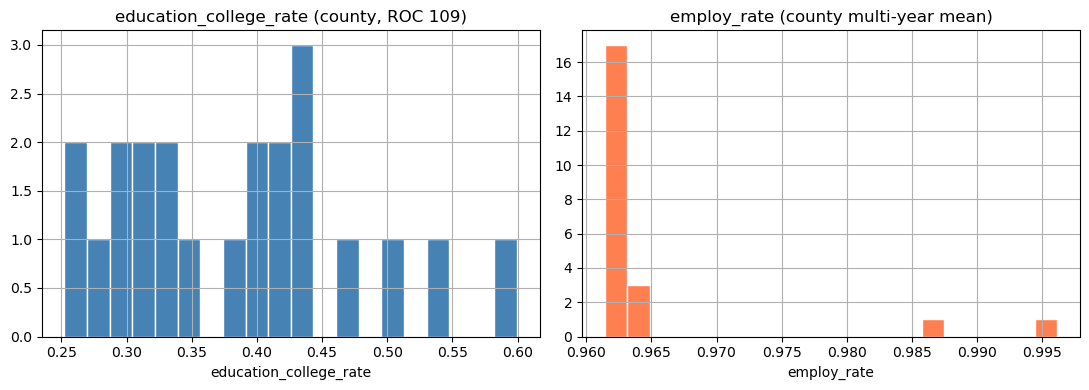


=== Highest education_college_rate counties ===
COUNTYNAME  education_college_rate
       臺北市                  0.5996
       新竹市                  0.5361
       新竹縣                  0.5075
       新北市                  0.4690
       桃園市                  0.4425

=== Lowest employ_rate counties ===
COUNTYNAME  employ_rate
       桃園市       0.9614
       基隆市       0.9615
       宜蘭縣       0.9618
       臺北市       0.9619
       新北市       0.9621


In [9]:
# %%
# 8. Validation and diagnostics

rate_cols = [c for c in FEATURE_COLS if c.endswith('_rate')]

print('=== Missing value summary ===')
missing = socioeconomic_features[FEATURE_COLS].isna().agg(['sum', 'mean'])
missing.index = ['missing_count', 'missing_ratio']
print(missing.round(4).to_string())

print('\n=== County replication check (same value within county) ===')
for col in FEATURE_COLS:
    n_unique = socioeconomic_features.groupby('COUNTYNAME')[col].nunique().max()
    if n_unique > 1:
        warnings.warn(f'{col}: max unique values per county = {n_unique}')
    else:
        print(f'{col}: OK (1 value per county)')

print('\n=== Sanity check (0 <= rate <= 1) ===')
for col in rate_cols + ['employ_rate']:
    if col not in socioeconomic_features.columns:
        continue
    valid = socioeconomic_features[col].dropna()
    bad = valid[(valid < 0) | (valid > 1)]
    if len(bad):
        warnings.warn(f'{col}: {len(bad)} values outside [0, 1]')
    else:
        print(f'{col}: OK ({len(valid)} non-null)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
county_view = socioeconomic_features.drop_duplicates('COUNTYNAME')
if 'education_college_rate' in county_view.columns:
    county_view['education_college_rate'].hist(
        ax=axes[0], bins=20, edgecolor='white', color='steelblue'
    )
    axes[0].set_title('education_college_rate (county, ROC 109)')
    axes[0].set_xlabel('education_college_rate')
county_view['employ_rate'].dropna().hist(
    ax=axes[1], bins=20, edgecolor='white', color='coral'
)
axes[1].set_title('employ_rate (county multi-year mean)')
axes[1].set_xlabel('employ_rate')
plt.tight_layout()
plt.show()

print('\n=== Highest education_college_rate counties ===')
top_edu = county_view.nlargest(5, 'education_college_rate')[
    ['COUNTYNAME', 'education_college_rate']
]
print(top_edu.round(4).to_string(index=False))

print('\n=== Lowest employ_rate counties ===')
low_emp = county_view.nsmallest(5, 'employ_rate')[['COUNTYNAME', 'employ_rate']]
print(low_emp.round(4).to_string(index=False))



## 9. Export processed datasets


In [10]:
# %%
# 9. Export processed datasets

socioeconomic_features.to_csv(OUT_CSV, index=False, encoding='utf-8-sig')

print('Saved:', OUT_CSV)
print('Shape:', socioeconomic_features.shape)
print('\nSample rows:')
print(socioeconomic_features.head(5).to_string(index=False))
print('\nTaiwan socioeconomic feature engineering completed.')



Saved: /Users/tingting/SolarPotentialMapping/data/taiwan/socioeconomic/taiwan_socioeconomic_features.csv
Shape: (368, 10)

Sample rows:
 TOWNCODE COUNTYNAME TOWNNAME  education_high_school_graduate  education_less_than_high_school  education_college  education_college_rate  education_high_school_graduate_rate  education_less_than_high_school_rate  employ_rate
  9007010        連江縣      南竿鄉                          3932.0                           2244.0             4336.0                0.412481                             0.374049                              0.213470     0.996182
  9007020        連江縣      北竿鄉                          3932.0                           2244.0             4336.0                0.412481                             0.374049                              0.213470     0.996182
  9007030        連江縣      莒光鄉                          3932.0                           2244.0             4336.0                0.412481                             0.374049            

## 總結

- **輸出**：`data/taiwan/socioeconomic/taiwan_socioeconomic_features.csv`
- **列**：368 鄉鎮（`TOWNCODE`）；縣市層資料下放，同縣市各鄉鎮相同
- **欄**：`TOWNCODE`, `COUNTYNAME`, `TOWNNAME` + 有資料之 DeepSolar 對應特徵（全缺欄位不輸出）
- **限制**：僅 DeepSolar top-90 對應欄位；不含 `unemployment_rate` 與台灣特有衍生欄
